# IMPORTS

In [ ]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import time
sys.path.append('../src') 

from utils.io import load_raw_image
from utils.normalize import normalize_min_max_values, denormalize_min_max_values
from utils.metrics import calculate_metrics, print_metrics

from coder_original import compress_v1, decompress_v1
from coder_wavefront_cpu import compress_wf_cpu, decompress_wf_cpu
from coder_parallel_cpu import compress_parallel_cpu, decompress_parallel_cpu
from coder_wavefront_cuda import compress_wf_cuda, decompress_wf_cuda
from coder_parallel_cuda import compress_parallel_cuda, decompress_parallel_cuda

# SET VALUES

In [8]:
DTYPE = np.float64
BLOCK_SIZE = 4
FIXED_INPUT_SIZE = 16
LEARNING_RATE = DTYPE(0.5)
MODE = 5

ALGORITHMS = {
    1: ("V1_Secuencial_Original", compress_v1, decompress_v1),
    2: ("V2_Wavefront_CPU", compress_wf_cpu, decompress_wf_cpu),
    3: ("V3_Parallel_CPU", compress_parallel_cpu, decompress_parallel_cpu),
    4: ("V2_Wavefront_CUDA", compress_wf_cuda, decompress_wf_cuda),
    5: ("V3_Parallel_CUDA", compress_parallel_cuda, decompress_parallel_cuda)
}

mode_name, compress_func, decompress_func = ALGORITHMS[MODE]

# 1. LOAD RAW IMAGE 1

Data Loaded. Shape: (2560, 2048)
Total pixels expected: 5242880
Total pixels loaded: 5242880


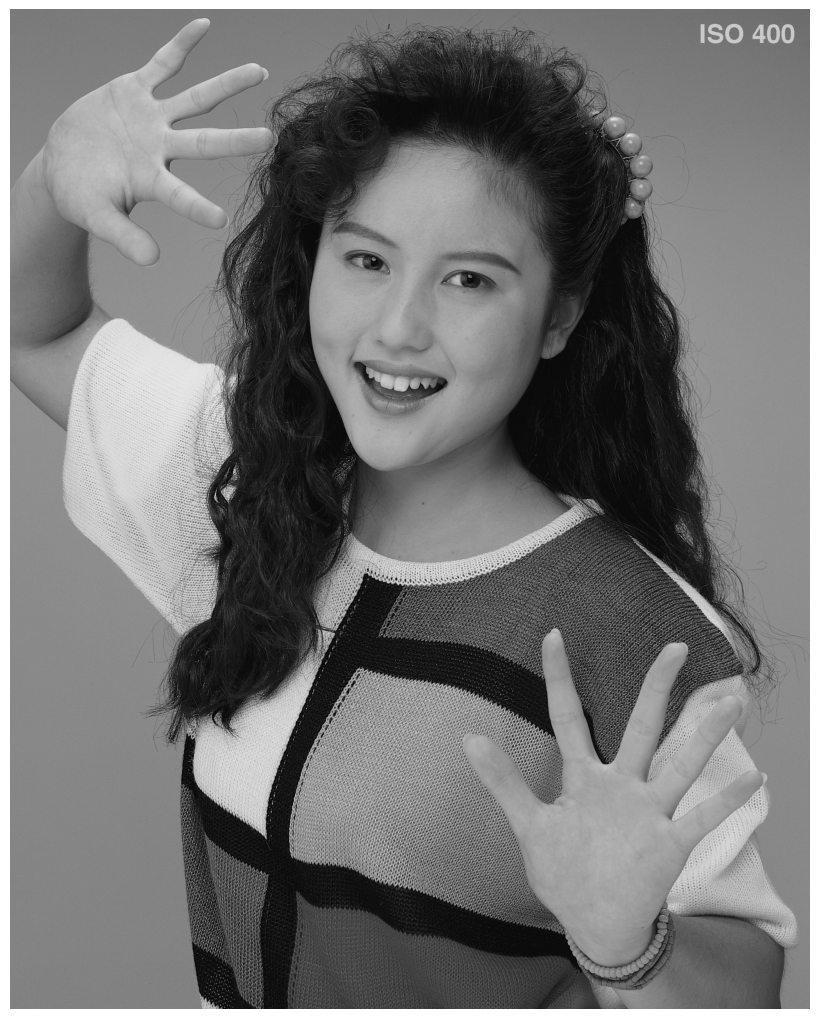

In [9]:
FILE_PATH = '../data/n1_GRAY.ube8_1_2560_2048.raw'

#Image dimensions and format
WIDTH = 2048
HEIGHT = 2560
CHANNELS = 1      
ENCODING = 'ube8'   

original_img = load_raw_image(FILE_PATH, WIDTH, HEIGHT, CHANNELS, ENCODING)

if original_img is not None:
    img = original_img['array']
    print(f"Data Loaded. Shape: {img.shape}")
    print(f"Total pixels expected: {WIDTH * HEIGHT}")
    print(f"Total pixels loaded: {img.size}")

    plt.figure(figsize=(15, 10))
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.tight_layout(pad=0)
    plt.show()
else:
    print("File not found.")

# 2. NORMALIZE TO [0 , 1]

In [10]:
orig_min, orig_max, norm_img = normalize_min_max_values(img, DTYPE)

# 3. COMPRESSION

Compression time: 0.2803 s
float64


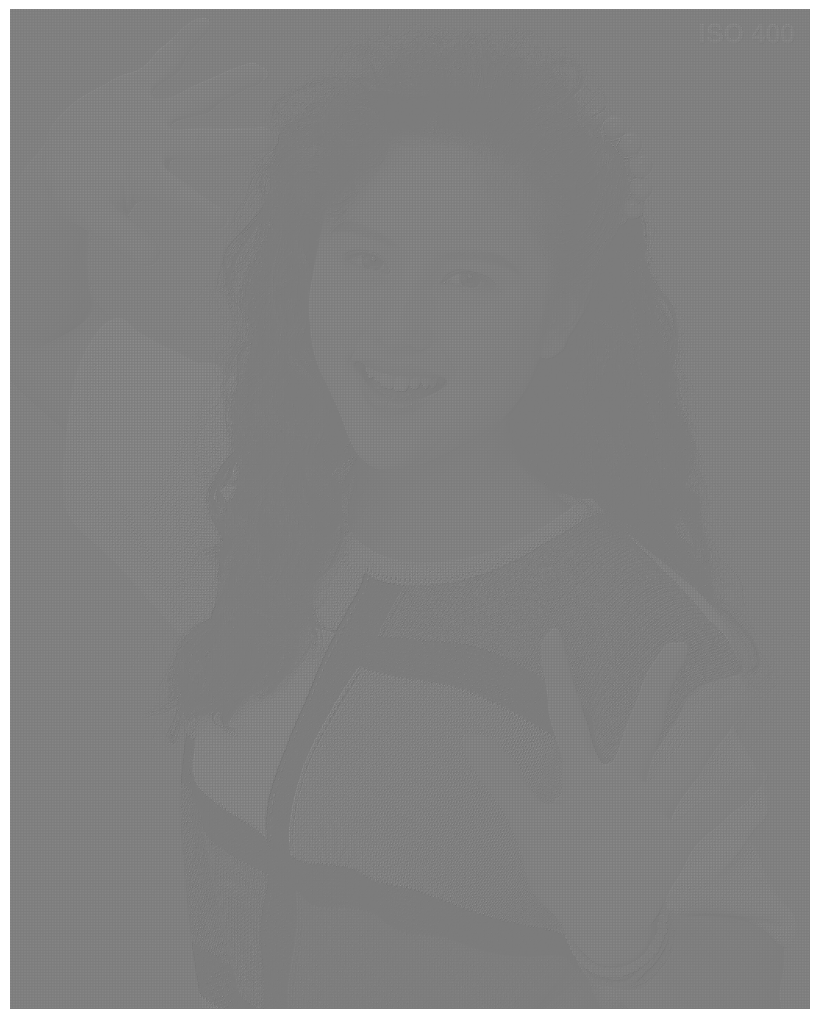

In [11]:
start_t = time.time()
error_map = compress_func(norm_img, BLOCK_SIZE, LEARNING_RATE, FIXED_INPUT_SIZE)
end_t = time.time()

print(f"Compression time: {end_t - start_t:.4f} s")
print(error_map.dtype)
plt.figure(figsize=(15, 10))
plt.imshow(error_map, cmap='gray')
plt.axis('off')
plt.tight_layout(pad=0) 
plt.show()

# 4. DECOMPRESSION

Decompression time: 0.0540 s


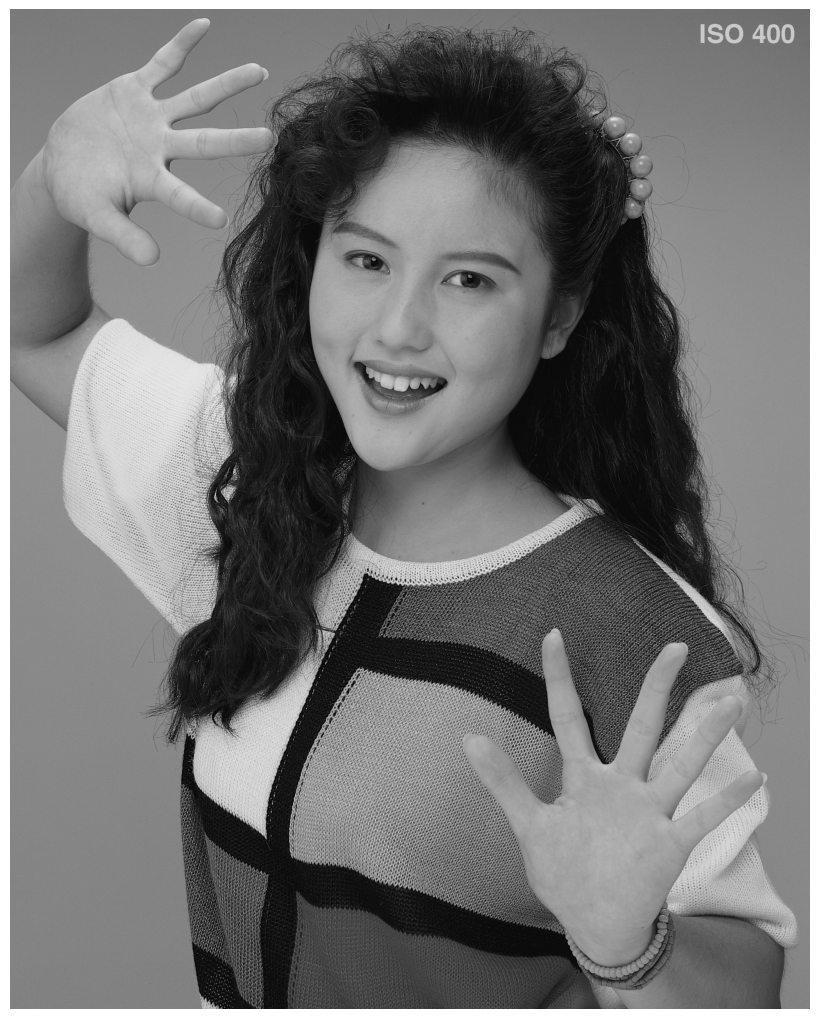

Peak Absolute Error (PAE): 0.0000
Mean Squared Error (MSE): 0.0000
Peak Signal-to-Noise Ratio (PSNR): inf dB


In [15]:
start_t = time.time()
rec_norm = decompress_func(error_map, BLOCK_SIZE, LEARNING_RATE, FIXED_INPUT_SIZE, original_shape=img.shape)
end_t = time.time()

print(f"Decompression time: {end_t - start_t:.4f} s")
plt.figure(figsize=(15, 10))
plt.imshow(rec_norm, cmap='gray')
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

rec_final = denormalize_min_max_values(rec_norm, orig_min, orig_max)
print_metrics(calculate_metrics(img.flatten(), rec_final.flatten(), original_img['params']['bits']))